# imports

In [1]:

import sionna.rt as rt

# Other imports
import matplotlib.pyplot as plt
import mitsuba as mi
import numpy as np
import tensorflow as tf
from metrics import compute_kpis, plot_kpis
from sim import simulate, build_rx_path, setup_drone_meshes
from sensing import make_scene, add_target_sphere, sense_snapshot, plot_range_doppler

# Import relevant components from Sionna RT
from sionna.rt import load_scene, PlanarArray, Transmitter, Receiver, Camera,\
                      PathSolver, RadioMapSolver, subcarrier_frequencies

# Query the Mitsuba variant that was automatically selected by Sionna RT.
# There should be no need to adjust it, but if you do, make sure to select
# a variant ending in `*_ad_mono_polarized`.
print(f"Mitsuba variant: {mi.variant()}")
print(tf.config.list_physical_devices('GPU'))


I0000 00:00:1783710590.494721   10088 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1783710590.772942   10088 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1783710592.012555   10088 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Mitsuba variant: cuda_ad_mono_polarized
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# Params

In [2]:
preview = False
render = False
generate_metrics = True
beamforming_on = True
precoder_alpha = 0.0    # RZF/MMSE regularization: 0 = pure ZF
csi_error_std = 0.00    # stddev of simulated per-entry CSI estimation error (0 = perfect CSI)
power_allocation = True # channel inversion: more power to weak users
tx_power_dbm = 30       # total tx power in dBm, split across users

# --- Sensing ---
sensing_on = True


# create scene

In [3]:
scene = load_scene(rt.scene.simple_street_canyon, merge_shapes=False)
scene.frequency = 28e9

# create transmitter and add it to the scene
scene.tx_array = PlanarArray(num_rows=8, num_cols=8, pattern="tr38901", polarization="V") #document these
scene.rx_array = scene.tx_array



In [4]:

# -----------------------------
# DEFINE CAMERAS
# -----------------------------
cameras = {
    #"cam1": Camera(position=[120, 5, 50], look_at=[15, 0, 0]),
    #,
    "cam2": Camera(position=[0, 0, 270], look_at=[0, 0, 0])
}

#------------------------------
# DEFINE DRONES
# -----------------------------
uas1 = rt.Receiver(name="uas_1", position=[-75.0, -5.0, 20.0], orientation=[0.0, 0.0, 0.0])
uas1.color=[1,1,0]
scene.add(uas1)
uas2 = rt.Receiver(name="uas_2", position=[-75.0, 0.0, 20.0], orientation=[0.0, 0.0, 0.0])
uas2.color=[1,0,1]
scene.add(uas2)
uas3 = rt.Receiver(name="uas_3", position=[-75.0, 5.0, 20.0], orientation=[0.0, 0.0, 0.0])
uas3.color=[0,1,1]
scene.add(uas3)

# create transmitter and add it to the scene
tx = rt.Transmitter(name="tx_1", position=[0.0, 0.0, 1.5])
tx.power_dbm = 30
scene.add(tx)

# -----------------------------
# CONFIG
# -----------------------------
num_drones = 3
num_steps = 5  # increased resolution
dt = 1        # smaller timestep

# -----------------------------
# BUILD RX PATHS [N, T, 3]
# -----------------------------
start_points = tf.constant([
    [-75, -5, 20],  # yellow
    [-75,  0, 20],  # cyan
    [-75,  5, 20]   # pink
], dtype=tf.float32)

base_velocities = tf.constant([
    [[0, -50,  0], [50, 0, 0], [50, 0, 0], [50, 0, 0], [00, 50, 0]],
    [[50, 0,  0], [0, 50, 0], [50, 0, 20], [0, -50, 0], [50, 0, 0]],
    [[25, 25, 15], [50, -50, 20], [0, 50, 0], [50, -50, -20], [0, 50, 0]]
], dtype=tf.float32)  # Shape: [N, _base_steps, 3]

rx_path = build_rx_path(start_points, base_velocities, num_steps, dt, on_mismatch="error")

I0000 00:00:1783710592.672821   10088 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3965 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


In [5]:
# -----------------------------
# JCAS INTEGRATION SETUP
# -----------------------------
# Add a metal sphere mesh for each drone so Sionna's ray tracer treats them as
# physical scatterers for comms multi-path off the drone body.
drone_meshes = setup_drone_meshes(scene, drone_radius_m=0.25)


In [6]:
# -----------------------------
# RUN SIMULATION
# -----------------------------
kpi_log = simulate(
    rx_path=rx_path,
    cameras=cameras,
    scene=scene,
    drone_meshes=drone_meshes,
    generate_metrics=generate_metrics,
    render=render,
    beamforming_on=beamforming_on,
    precoder_alpha=precoder_alpha,
    csi_error_std=csi_error_std,
    power_allocation=power_allocation,
    tx_power_dbm=tx_power_dbm
)

Step 0: {'uas_1': {'sinr_db': np.float64(-0.8840231827974281), 'ber': 0.10073731670578229, 'throughput_mbps': 86.06, 'coverage_fraction': 0.3288, 'tx_power_dbm': 29.43, 'position': [[-75.0], [-5.0], [20.0]]}, 'uas_2': {'sinr_db': np.float64(-13.475645738315727), 'ber': 0.3821908993253568, 'throughput_mbps': 6.34, 'coverage_fraction': 0.1338, 'tx_power_dbm': 14.99, 'position': [[-75.0], [0.0], [20.0]]}, 'uas_3': {'sinr_db': np.float64(-16.16698612430906), 'ber': 0.4129862567114268, 'throughput_mbps': 3.45, 'coverage_fraction': 0.1888, 'tx_power_dbm': 19.63, 'position': [[-75.0], [5.0], [20.0]]}}
Step 1: {'uas_1': {'sinr_db': np.float64(-41.47702028708515), 'ber': 0.49524047353024137, 'throughput_mbps': 0.01, 'coverage_fraction': 0.3376, 'tx_power_dbm': 30.0, 'position': [[-75.0], [-55.0], [20.0]]}, 'uas_2': {'sinr_db': np.float64(-62.83734095551485), 'ber': 0.49959303417525813, 'throughput_mbps': 0.0, 'coverage_fraction': 0.0, 'tx_power_dbm': -55.46, 'position': [[-25.0], [0.0], [20.0]]

In [7]:
# -----------------------------
# SENSING SIMULATION
# -----------------------------
# Directional 8x8 array (not SISO): the radar sits at the west end of the
# street (edge of the modeled buildings) and its boresight points straight
# down the street corridor toward the east end -- both fixed, scene-geometry
# coordinates, NOT derived from the drones' actual position (that would be
# cheating: a real radar doesn't get to aim at ground truth). Directivity
# still suppresses off-axis near-field clutter, the same mechanism real
# automotive radar relies on, but honestly the targets won't always dominate
# every frame this way -- a real fixed-boresight radar wouldn't either.
# See sensing.py's module docstring for why this needs its own path solve
# rather than HermesPy's built-in SionnaRTChannel (that class's per-sample
# MIMO convolution runs out of GPU memory for a 64-element array).

drone_names = list(scene.receivers)
bs_pos = [-60.0, 0.0, 1.5]         # west edge of the modeled street canyon
look_at_point = [60.0, 0.0, 1.5]   # east edge -- straight down the corridor
tx_power_w = 10 ** (tx_power_dbm / 10) / 1000

sensing_cubes = []  # [T] one RadarCube per timestep

if sensing_on:
    radar_scene = make_scene(rt.scene.simple_street_canyon)
    spheres = {
        name: add_target_sphere(radar_scene, position=rx_path[i, 0, :].numpy().tolist(), name=name)
        for i, name in enumerate(drone_names)
    }

    for t in range(num_steps):
        for i, name in enumerate(drone_names):
            spheres[name].position = rx_path[i, t, :].numpy().tolist()
            # Velocity lets Sionna's PathSolver compute correct Doppler --
            # position alone is static per drop, so Doppler is zero without it.
            t_next = min(t + 1, num_steps - 1)
            vel = (rx_path[i, t_next, :] - rx_path[i, t, :]).numpy() / dt
            spheres[name].velocity = vel.tolist()

        cube = sense_snapshot(radar_scene, bs_position=bs_pos, look_at=look_at_point, tx_power_w=tx_power_w)
        sensing_cubes.append(cube)
        print(f"Sensing t={t}: peak power {cube.data.max():.3e}, "
              f"peak range {cube.range_bins[cube.data.max(axis=(0,1)).argmax()]:.1f}m")

Sensing t=0: peak power 4.140e-01, peak range 54.0m
Sensing t=1: peak power 4.148e-01, peak range 54.0m
Sensing t=2: peak power 4.139e-01, peak range 54.0m
Sensing t=3: peak power 4.144e-01, peak range 54.0m
Sensing t=4: peak power 1.664e+00, peak range 93.0m


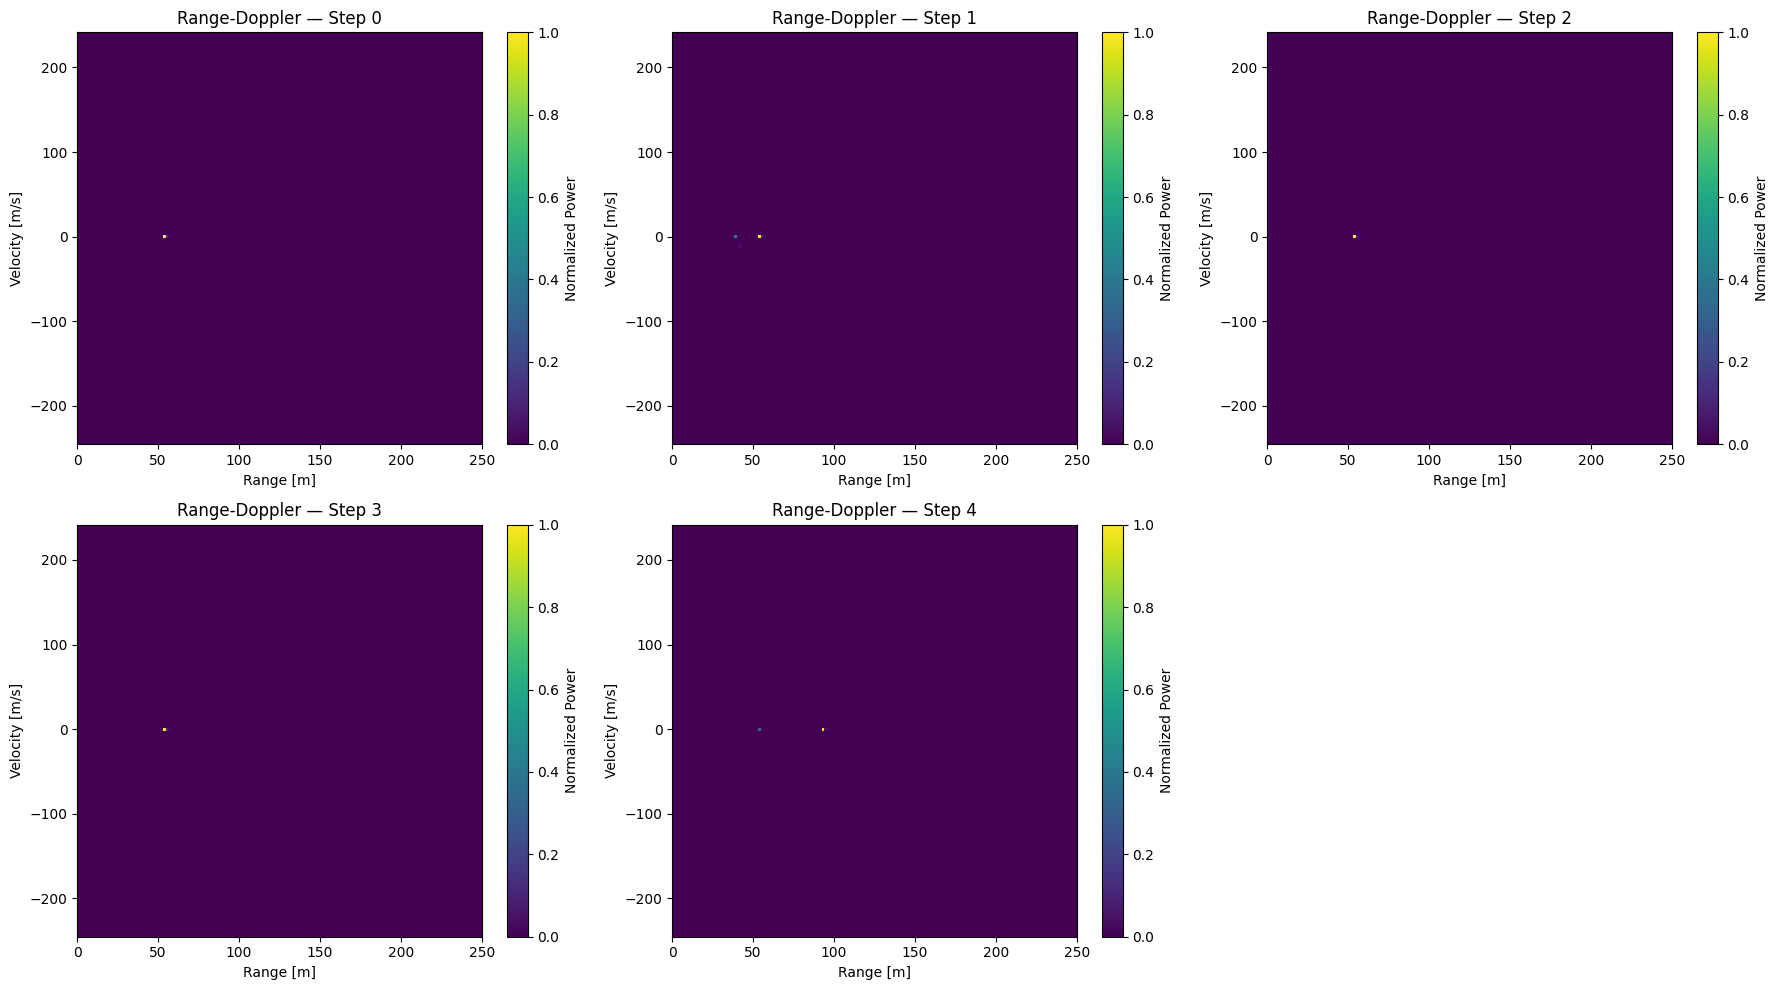

In [8]:
# -----------------------------
# SENSING PLOTS
# -----------------------------
if sensing_on and sensing_cubes:
    n_steps_plotted = len(sensing_cubes)
    ncols = 3
    nrows = -(-n_steps_plotted // ncols)

    fig = plt.figure(figsize=(6 * ncols, 5 * nrows))
    for t_idx in range(n_steps_plotted):
        ax = fig.add_subplot(nrows, ncols, t_idx + 1)
        plot_range_doppler(
            sensing_cubes[t_idx],
            max_range_m=250,
            ax=ax,
            title=f"Range-Doppler — Step {t_idx}",
        )
    plt.tight_layout()
    plt.show()

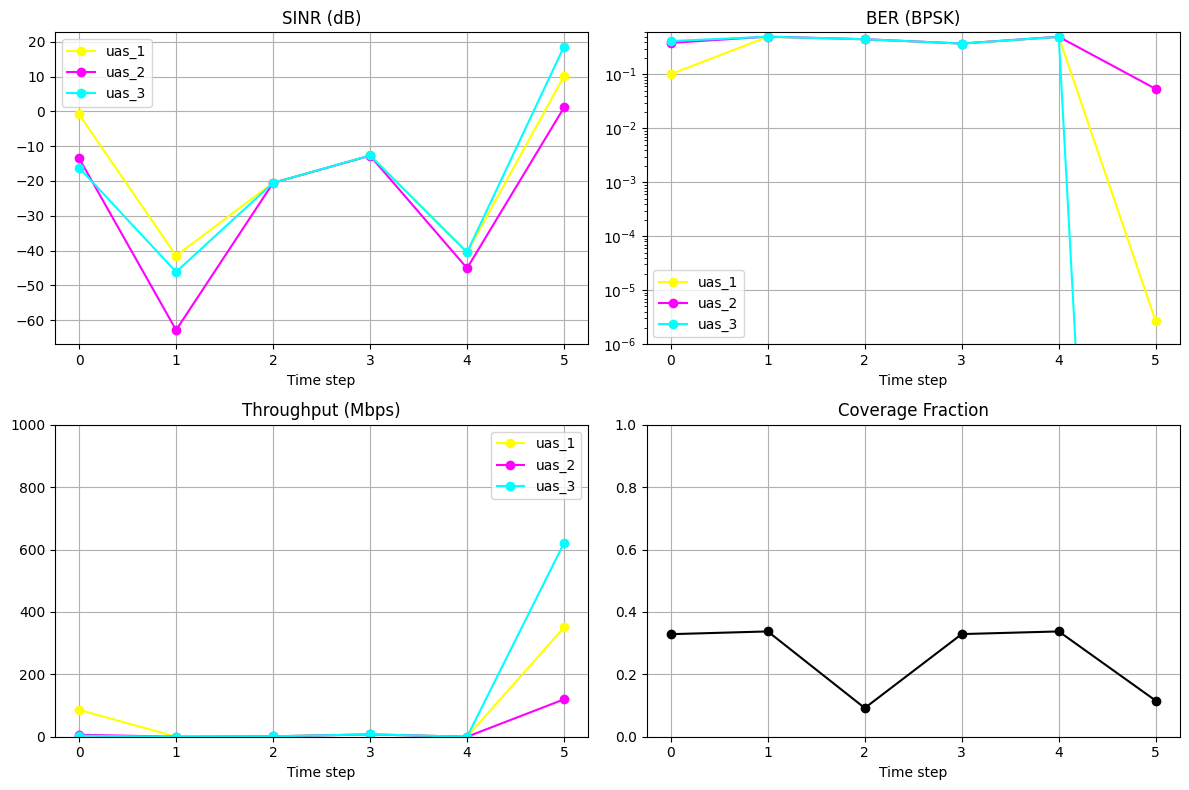

In [9]:
# -----------------------------
# PLOT KPIs
# -----------------------------
plot_kpis(kpi_log, scene)